<a href="https://colab.research.google.com/github/MariaCarolinass/analise-sinais/blob/main/arvore_decisao_sinais_cardiotocografia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de dados de cardiotocografia (CTG)

## Introdução e objetivos

A cardiotocografia (CTG) é um exame que avalia o bem-estar fetal através do registro da frequência cardíaca fetal e das contrações uterinas. Vamos estudar a relação entre a Frequência Cardíaca Fetal (FHR) e a Contração Uterina (UC). Os dados foram pegos do [CTU-CHB Intrapartum Cardiotocography Database](https://physionet.org/content/ctu-uhb-ctgdb/1.0.0/).

O database possuí uma colação de 552 CTGs da Universidade Técnica Tcheca, onde foram extraídos 9164 gravações coletadas no Hospital Universitário de Brno entre 2010 e 2012. Cada gravação tem até 90 minutos de duração e inclui uma série temporal de frequência cardíaca fetal, um sinal de contração uterina e detalhes clínicos maternos, de parto e do feto.

Critérios do database:

- Gravidez de Singleton (ou gestação única)
- Idade gestacional? 36 semanas
- Não há defeitos de desenvolvimento conhecidos a a priori
- Duração da fase 2 do trabalho de parto? 30 minutes
- Qualidade do sinal FHR (ou seja, porcentagem do registro durante o qual os dados de FHR estavam disponíveis) ? 50% em cada janela de 30 minutos
- Análise disponível dos parâmetros bioquímicos da amostra de sangue arterial umbilical (i.e. pH)
- Maioria dos partos vaginais (apenas 46 partos cesáreo (CS) incluídos)

Cada CTG contém uma série temporal de frequência cardíaca fetal (FCC) e um sinal de contração uterina (UC), cada um amostrado a 4 Hz.

## Baixando dados

In [1]:
!wget -r -N -c -np https://physionet.org/files/ctu-uhb-ctgdb/1.0.0/

A saída de streaming foi truncada nas últimas 5000 linhas.
Length: 84024 (82K) [application/octet-stream]
Saving to: ‘physionet.org/files/ctu-uhb-ctgdb/1.0.0/1305.dat’

physionet.org/files 100%[===================>]  82.05K   216KB/s    in 0.4s    

2026-03-25 13:57:51 (216 KB/s) - ‘physionet.org/files/ctu-uhb-ctgdb/1.0.0/1305.dat’ saved [84024/84024]

--2026-03-25 13:57:51--  https://physionet.org/files/ctu-uhb-ctgdb/1.0.0/1305.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 929 [text/plain]
Saving to: ‘physionet.org/files/ctu-uhb-ctgdb/1.0.0/1305.hea’

physionet.org/files 100%[===================>]     929  --.-KB/s    in 0s      

2026-03-25 13:57:51 (554 MB/s) - ‘physionet.org/files/ctu-uhb-ctgdb/1.0.0/1305.hea’ saved [929/929]

--2026-03-25 13:57:51--  https://physionet.org/files/ctu-uhb-ctgdb/1.0.0/1306.dat
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 62400 (61

In [3]:
%cd /content/physionet.org/files/ctu-uhb-ctgdb/1.0.0/

/content/physionet.org/files/ctu-uhb-ctgdb/1.0.0


## Bibliotecas

In [1]:
!pip install wfdb -q

In [2]:
import os
import wfdb
import numpy as np
import pandas as pd
from scipy import signal

## Processando de Dados

In [4]:
record_files = [f for f in os.listdir('.') if f.endswith('.dat')]

record_names = [os.path.splitext(f)[0] for f in record_files]

record_names.sort(key=int)

print(f"Foram encontrados {len(record_names)} registros para processar.")
print(record_names[:10])

Foram encontrados 552 registros para processar.
['1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008', '1009', '1010']


In [9]:
def extract_features_and_target(record_name):
    try:
        record = wfdb.rdrecord(record_name)
        signals = record.p_signal
        fs = record.fs

        fhr = signals[:, 0].astype(float)
        uc = signals[:, 1].astype(float)

        fhr[fhr < 0] = np.nan
        uc[uc < 0] = np.nan

        # remoção de ruídos no sinal FHR
        fhr_kernel = signal.windows.gaussian(M=101, std=25)
        fhr_kernel = fhr_kernel / np.sum(fhr_kernel)
        fhr_med = signal.medfilt(fhr[~np.isnan(fhr)], kernel_size=11)
        fhr_suave = np.convolve(fhr_med, fhr_kernel, mode='same')

        # remoção de ruídos no sinal UC
        uc_kernel = signal.windows.gaussian(M=25, std=8)
        uc_kernel = uc_kernel / np.sum(uc_kernel)
        uc_med = signal.medfilt(uc[~np.isnan(uc)], kernel_size=11)
        uc_suave = np.convolve(uc_med, uc_kernel, mode='same')

        features = {'Record_ID': record_name}

        # Resultados FHR
        features['FHR_Mean'] = np.nanmean(fhr_suave) if fhr_suave.size > 0 and not np.all(np.isnan(fhr_suave)) else np.nan
        features['FHR_Median'] = np.nanmedian(fhr_suave) if fhr_suave.size > 0 and not np.all(np.isnan(fhr_suave)) else np.nan
        features['FHR_Std'] = np.nanstd(fhr_suave) if fhr_suave.size > 0 and not np.all(np.isnan(fhr_suave)) else np.nan
        features['FHR_Min'] = np.nanmin(fhr_suave) if fhr_suave.size > 0 and not np.all(np.isnan(fhr_suave)) else np.nan
        features['FHR_Max'] = np.nanmax(fhr_suave) if fhr_suave.size > 0 and not np.all(np.isnan(fhr_suave)) else np.nan

        # Resultados UC
        features['UC_Mean'] = np.nanmean(uc_suave) if uc_suave.size > 0 and not np.all(np.isnan(uc_suave)) else np.nan
        features['UC_Median'] = np.nanmedian(uc_suave) if uc_suave.size > 0 and not np.all(np.isnan(uc_suave)) else np.nan
        features['UC_Std'] = np.nanstd(uc_suave) if uc_suave.size > 0 and not np.all(np.isnan(uc_suave)) else np.nan
        features['UC_Min'] = np.nanmin(uc_suave) if uc_suave.size > 0 and not np.all(np.isnan(uc_suave)) else np.nan
        features['UC_Max'] = np.nanmax(uc_suave) if uc_suave.size > 0 and not np.all(np.isnan(uc_suave)) else np.nan

        ph_value = None
        for comment in record.comments:
            if 'pH' in comment:
                try:
                    ph_value = float(comment.split()[1])
                    break
                except (ValueError, IndexError):
                    continue

        if ph_value is not None:
            features['pH'] = ph_value
            features['pH_Status'] = 'normal' if ph_value >= 7.2 else 'anormal'
        else:
            features['pH'] = np.nan
            features['pH_Status'] = np.nan

        return features

    except Exception as e:
        print(f"Erro ao processar registro: {record_name}: {e}")
        return {'Record_ID': record_name, 'FHR_Mean': np.nan, 'FHR_Median': np.nan, 'FHR_Std': np.nan,
                'FHR_Min': np.nan, 'FHR_Max': np.nan, 'UC_Mean': np.nan, 'UC_Median': np.nan,
                'UC_Std': np.nan, 'UC_Min': np.nan, 'UC_Max': np.nan, 'pH': np.nan, 'pH_Status': np.nan}

In [10]:
all_features = []

sample_record_names = record_names

for i, name in enumerate(sample_record_names):
    print(f"Processando registro {i+1}/{len(sample_record_names)}: {name}")
    record_features = extract_features_and_target(name)
    all_features.append(record_features)

Processando registro 1/552: 1001
Processando registro 2/552: 1002
Processando registro 3/552: 1003
Processando registro 4/552: 1004
Processando registro 5/552: 1005
Processando registro 6/552: 1006
Processando registro 7/552: 1007
Processando registro 8/552: 1008
Processando registro 9/552: 1009
Processando registro 10/552: 1010
Processando registro 11/552: 1011
Processando registro 12/552: 1012
Processando registro 13/552: 1013
Processando registro 14/552: 1014
Processando registro 15/552: 1015
Processando registro 16/552: 1016
Processando registro 17/552: 1017
Processando registro 18/552: 1018
Processando registro 19/552: 1019
Processando registro 20/552: 1020
Processando registro 21/552: 1021
Processando registro 22/552: 1022
Processando registro 23/552: 1023
Processando registro 24/552: 1024
Processando registro 25/552: 1025
Processando registro 26/552: 1026
Processando registro 27/552: 1027
Processando registro 28/552: 1028
Processando registro 29/552: 1029
Processando registro 30

In [11]:
df_final_features = pd.DataFrame(all_features)

display(df_final_features.head())
display(df_final_features.info())

,Record_ID,FHR_Mean,FHR_Median,FHR_Std,FHR_Min,FHR_Max,UC_Mean,UC_Median,UC_Std,UC_Min,UC_Max,pH,pH_Status
0,1001,107.801076,132.653890,50.442122,0.0,166.900784,24.823847,23.265812,21.727742,0.0,119.067060,7.14,anormal
1,1002,123.251377,147.257953,46.716517,0.0,181.838300,24.675554,21.352084,22.968441,0.0,123.301679,7.00,anormal
2,1003,96.996672,123.177452,50.170373,0.0,152.909175,14.875000,3.000000,21.507253,0.0,100.000000,7.20,normal
3,1004,132.984572,138.044416,23.318098,0.0,162.836976,21.938956,8.201031,29.426845,0.0,100.000000,7.30,normal
4,1005,93.180556,114.620719,46.407377,0.0,159.528641,15.313139,14.420657,15.996586,0.0,117.958838,7.30,normal


<class 'pandas.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Record_ID   552 non-null    str    
 1   FHR_Mean    552 non-null    float64
 2   FHR_Median  552 non-null    float64
 3   FHR_Std     552 non-null    float64
 4   FHR_Min     552 non-null    float64
 5   FHR_Max     552 non-null    float64
 6   UC_Mean     552 non-null    float64
 7   UC_Median   552 non-null    float64
 8   UC_Std      552 non-null    float64
 9   UC_Min      552 non-null    float64
 10  UC_Max      552 non-null    float64
 11  pH          552 non-null    float64
 12  pH_Status   552 non-null    str    
dtypes: float64(11), str(2)
memory usage: 61.8 KB


None

### Construindo e Avaliando a Árvore de Decisão

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

X = df_final_features.drop(['Record_ID', 'pH', 'pH_Status'], axis=1)
y = df_final_features['pH_Status']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (386, 10)
X_test: (166, 10)
y_train: (386,)
y_test: (166,)


In [13]:
dtc = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

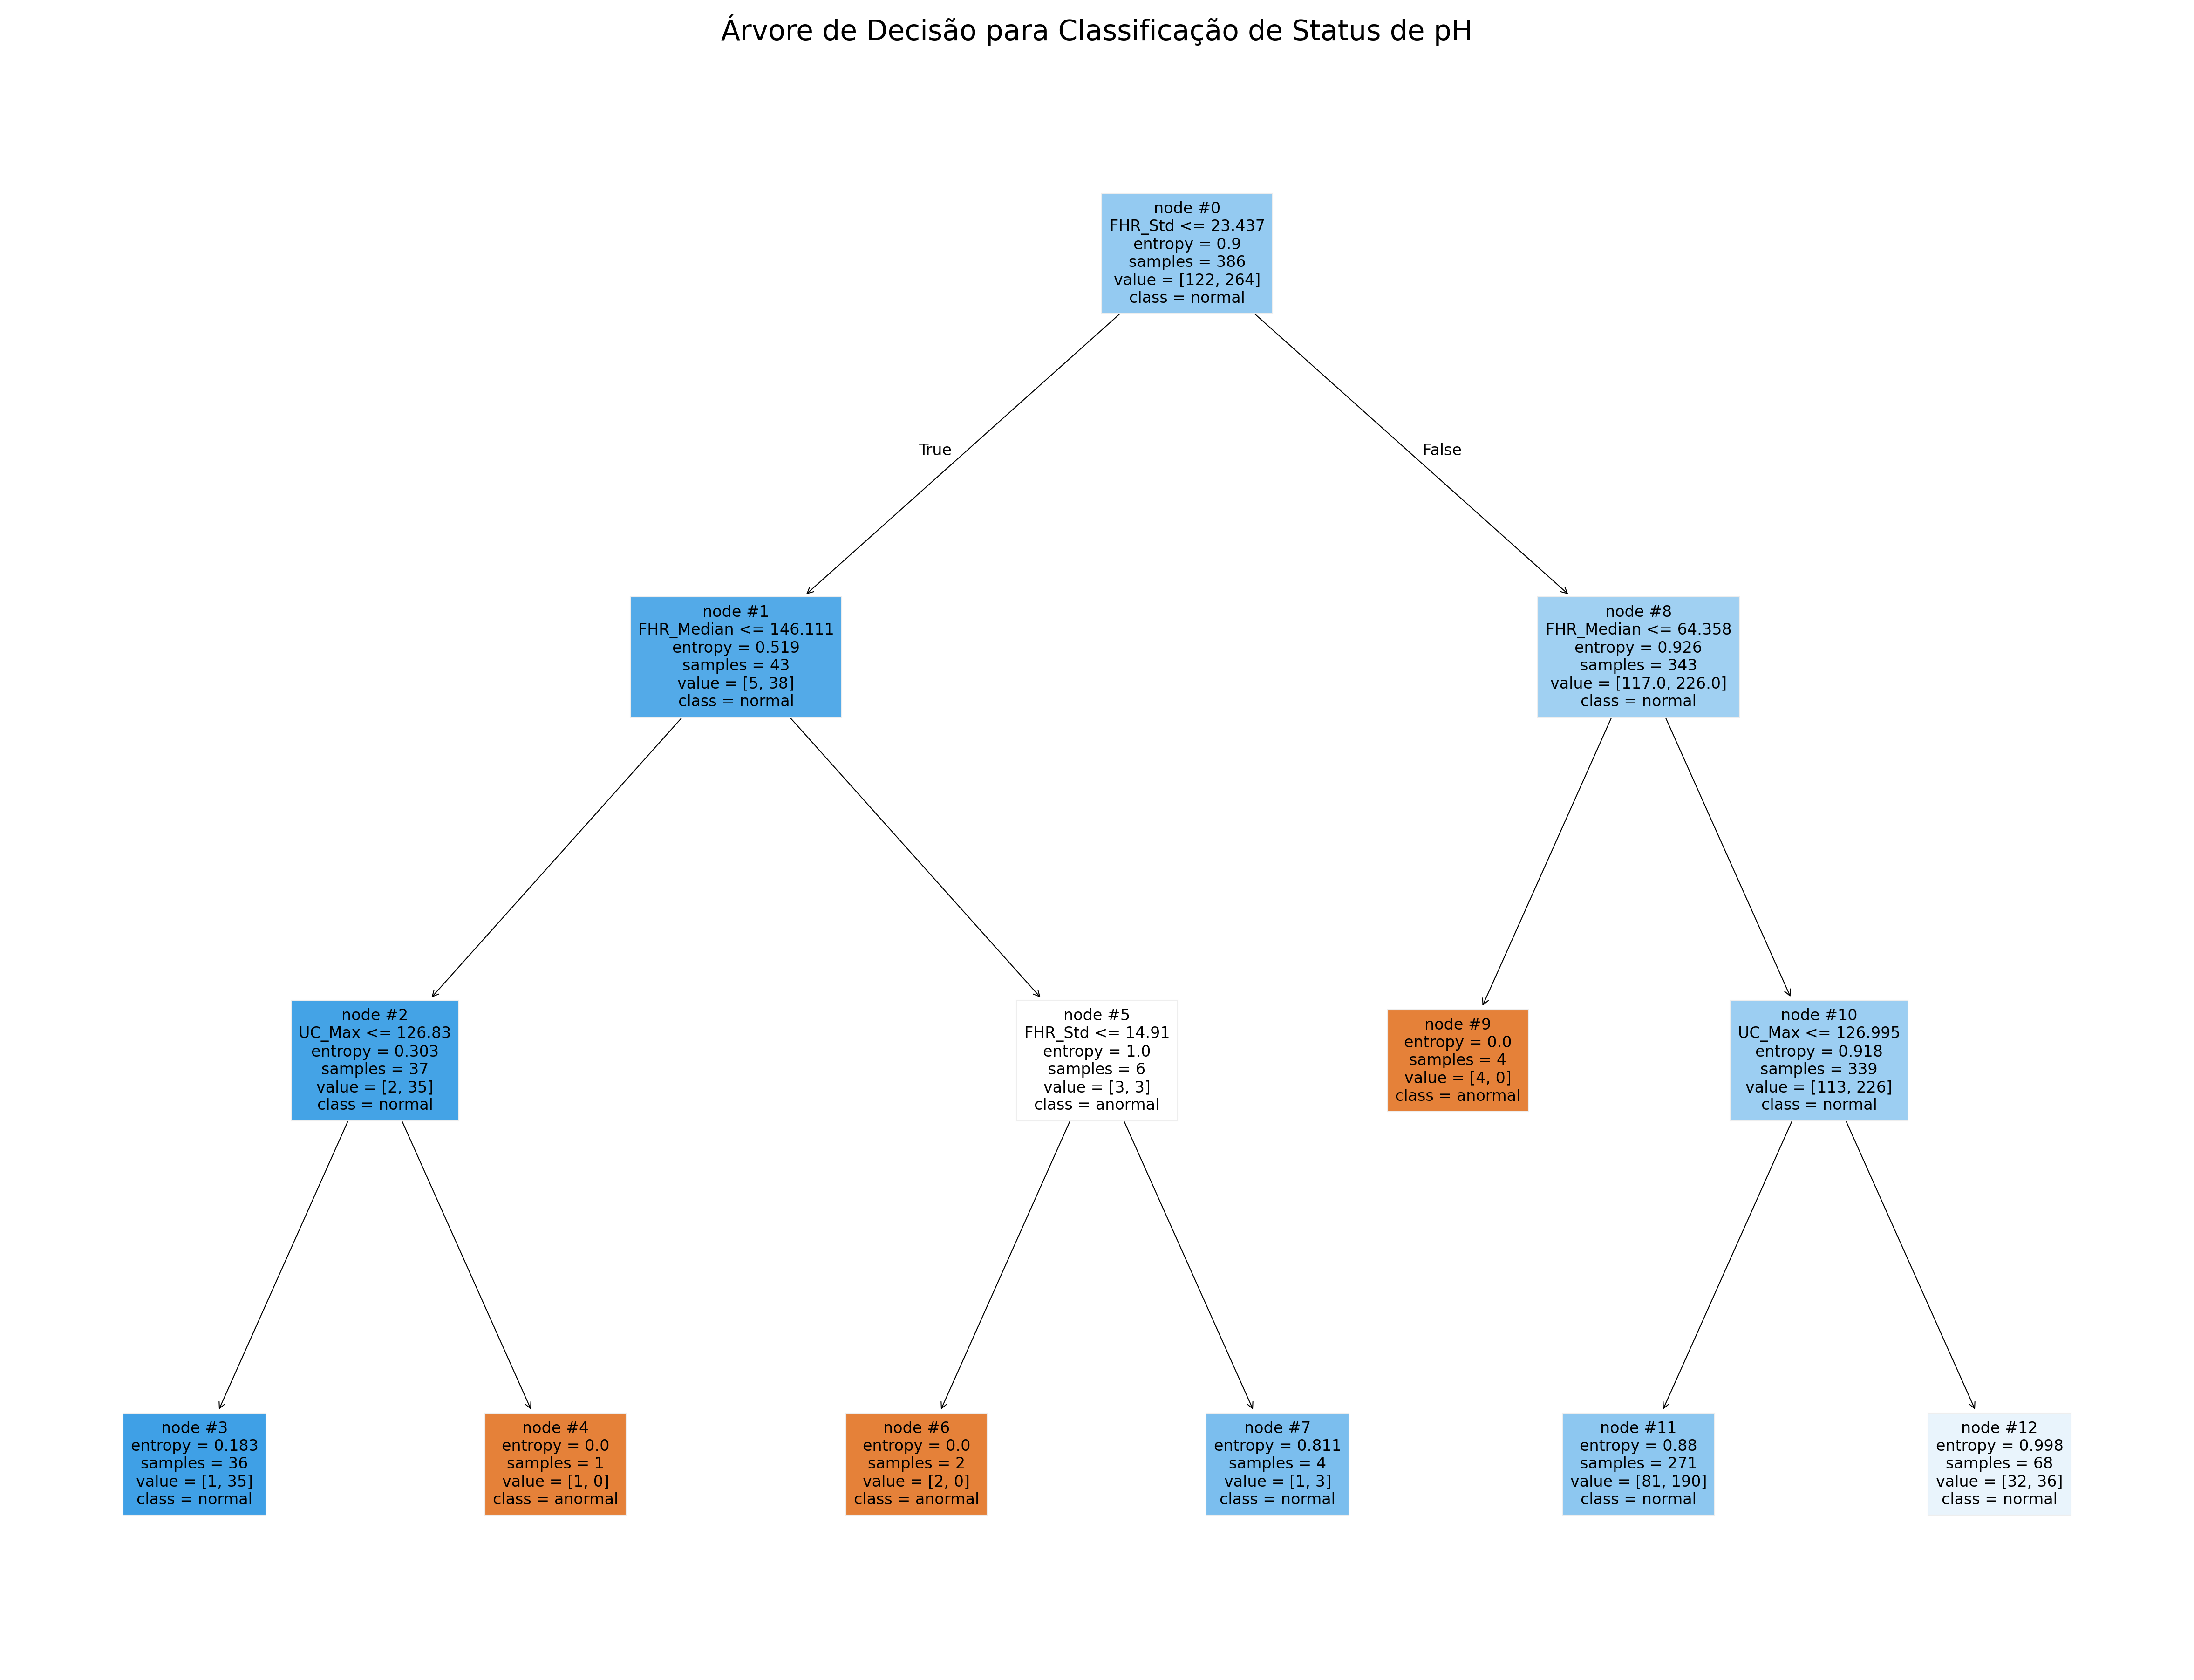

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.style.use('ggplot')

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (20, 15), dpi=300)
plot_tree(dtc,
           feature_names=X.columns.tolist(),
           class_names=label_encoder.classes_,
           filled=True,
           node_ids=True,
           fontsize=8)

plt.title('Árvore de Decisão para Classificação de Status de pH')
plt.show()

In [15]:
y_pred = dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f"Acurácia: {accuracy:.4f}")
print("Relatório de Classificação:")
print(report)

Acurácia: 0.6867
Relatório de Classificação:
              precision    recall  f1-score   support

     anormal       1.00      0.05      0.10        55
      normal       0.68      1.00      0.81       111

    accuracy                           0.69       166
   macro avg       0.84      0.53      0.46       166
weighted avg       0.79      0.69      0.58       166



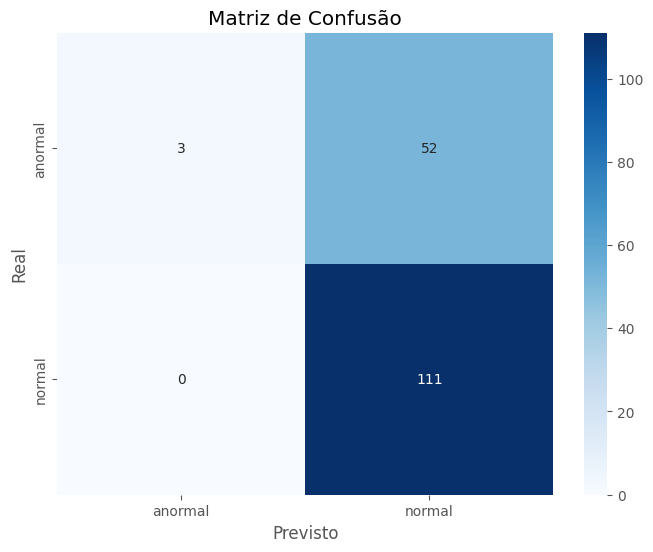

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()